# LSTM: Do 48-Hour Weather Sequences Add Signal Beyond Rolling Averages?

**Scientific question**: Does the temporal pattern of the 48h pre-onset weather carry information beyond `rolling_temp_max_24h` and `rolling_temp_max_48h` already summarised in LR M1?

Comparison baseline: LR M1 (Test AUC 0.6624).

## 1. Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import pickle

FEATURES_PATH = '../data/features_v2.parquet'
FIGURES_PATH  = '../figures/'
MODELS_PATH   = '../models/'

TRAIN_YEARS = list(range(2015, 2022))
VAL_YEARS   = [2022]
TEST_YEARS  = [2023, 2024]
SEQ_LEN     = 48
RANDOM_SEED = 42
NEG_RATIO   = 10
TARGET      = 'is_onset'

SEQUENCE_FEATURES = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'precipitation',
    'shortwave_radiation',
]
N_FEAT = len(SEQUENCE_FEATURES)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
print(f'Sequence features: {SEQUENCE_FEATURES}')
print(f'Sequence length  : {SEQ_LEN} hours')

PyTorch 2.11.0  |  device: mps
Sequence features: ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'shortwave_radiation']
Sequence length  : 48 hours


## 2. Load Data and Build Unit Lookup

In [2]:
print('Loading features_v2.parquet ...')
df = pd.read_parquet(FEATURES_PATH)
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values(['EICCode', 'DateTime']).reset_index(drop=True)
print(f'  Loaded: {df.shape[0]:,} rows')

train_df = df[df['year'].isin(TRAIN_YEARS)].copy()
val_df   = df[df['year'].isin(VAL_YEARS)].copy()
test_df  = df[df['year'].isin(TEST_YEARS)].copy()

# Pre-compute per-unit feature arrays and datetime index for fast sequence lookup
print('Pre-computing per-unit feature arrays ...')
unit_feats = {}   # EICCode -> float32 array (n_hours, 5)
unit_dts   = {}   # EICCode -> np.datetime64 array (sorted)

for unit, grp in df.groupby('EICCode'):
    arr = grp[SEQUENCE_FEATURES].fillna(0.0).values.astype(np.float32)
    unit_feats[unit] = arr
    unit_dts[unit]   = grp['DateTime'].values

print(f'  {len(unit_feats)} units cached')

for name, s in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n = len(s); k = s[TARGET].sum()
    print(f'  {name}: {n:>9,} rows | {k:>5,} onsets | {k/n*100:.4f}%')

Loading features_v2.parquet ...


  Loaded: 11,935,399 rows


Pre-computing per-unit feature arrays ...


  185 units cached
  Train: 8,698,327 rows | 7,113 onsets | 0.0818%
  Val: 1,127,257 rows |   952 onsets | 0.0845%
  Test: 2,109,815 rows | 1,767 onsets | 0.0838%


## 3. Sequence Construction and Stratified Sampling

In [3]:
def get_sequence(unit, target_dt):
    arr  = unit_feats[unit]
    dts  = unit_dts[unit]
    pos  = int(np.searchsorted(dts, np.datetime64(target_dt)))
    start = max(0, pos - SEQ_LEN + 1)
    seq   = arr[start : pos + 1]
    if len(seq) < SEQ_LEN:
        pad = np.zeros((SEQ_LEN - len(seq), N_FEAT), dtype=np.float32)
        seq = np.vstack([pad, seq])
    return seq.astype(np.float32)

def build_sample(split_df, neg_ratio, seed):
    pos       = split_df[split_df[TARGET] == 1]
    neg       = split_df[split_df[TARGET] == 0].copy()
    n_neg_need = len(pos) * neg_ratio

    neg['_fuel'] = np.where(neg['fuel_Fossil Gas'] > 0.5, 'Gas',
                   np.where(neg['fuel_Fossil Brown coal/Lignite'] > 0.5, 'Lignite', 'HCoal'))
    neg['_month']   = neg['DateTime'].dt.month
    neg['_stratum'] = neg['_fuel'] + '_' + neg['_month'].astype(str)

    sampled = neg.groupby('_stratum', group_keys=False).apply(
        lambda x: x.sample(
            min(len(x), max(1, int(round(n_neg_need * len(x) / len(neg))))),
            random_state=seed
        )
    )
    # top-up if stratified sampling fell short
    shortage = n_neg_need - len(sampled)
    if shortage > 0:
        leftover = neg[~neg.index.isin(sampled.index)]
        extra    = leftover.sample(min(shortage, len(leftover)), random_state=seed)
        sampled  = pd.concat([sampled, extra])

    sampled = sampled.sample(min(n_neg_need, len(sampled)), random_state=seed)
    return pd.concat([pos, sampled]).sample(frac=1, random_state=seed).reset_index(drop=True)

print('Sampling ...')
train_sample = build_sample(train_df, NEG_RATIO, 42)
val_sample   = build_sample(val_df,   NEG_RATIO, 43)
test_sample  = build_sample(test_df,  NEG_RATIO, 44)
for name, s in [('Train', train_sample), ('Val', val_sample), ('Test', test_sample)]:
    k = s[TARGET].sum(); n = len(s)
    print(f'  {name}: {n:>7,} rows | {k:>5,} onsets ({k/n*100:.1f}%)')

print('\nBuilding sequence tensors ...')
def build_tensors(sample_df):
    X = np.zeros((len(sample_df), SEQ_LEN, N_FEAT), dtype=np.float32)
    y = sample_df[TARGET].values.astype(np.float32)
    for i, (_, row) in enumerate(sample_df.iterrows()):
        X[i] = get_sequence(row['EICCode'], row['DateTime'])
    return X, y

X_tr, y_tr = build_tensors(train_sample)
X_va, y_va = build_tensors(val_sample)
X_te, y_te = build_tensors(test_sample)

# Z-score normalise on train statistics
feat_mean = X_tr[:, -1, :].mean(axis=0)
feat_std  = X_tr[:, -1, :].std(axis=0) + 1e-8
print(f'\nFeature means: {np.round(feat_mean, 2)}')
print(f'Feature stds : {np.round(feat_std,  2)}')

X_tr = (X_tr - feat_mean) / feat_std
X_va = (X_va - feat_mean) / feat_std
X_te = (X_te - feat_mean) / feat_std

print(f'\n  Train : {X_tr.shape}  range [{X_tr.min():.2f}, {X_tr.max():.2f}]')
print(f'  Val   : {X_va.shape}')
print(f'  Test  : {X_te.shape}')

Sampling ...


  Train:  78,243 rows | 7,113 onsets (9.1%)
  Val:  10,472 rows |   952 onsets (9.1%)
  Test:  19,437 rows | 1,767 onsets (9.1%)

Building sequence tensors ...



Feature means: [1.0840e+01 7.6330e+01 3.4400e+00 8.0000e-02 1.2959e+02]
Feature stds : [  7.7   16.31   1.83   0.31 201.22]

  Train : (78243, 48, 5)  range [-4.68, 65.73]
  Val   : (10472, 48, 5)
  Test  : (19437, 48, 5)


## 4. LSTM Architecture

In [4]:
class OutageLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),   # raw logits — sigmoid applied at inference
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        return self.classifier(last).squeeze(-1)


class OnsetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


model = OutageLSTM().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

OutageLSTM(
  (lstm): LSTM(5, 32, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

Trainable parameters: 13,985


## 5. Training

In [5]:
BATCH_SIZE  = 256
MAX_EPOCHS  = 20
LR          = 0.001
POS_WEIGHT  = 10.0
PATIENCE    = 3

train_loader = DataLoader(OnsetDataset(X_tr, y_tr), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(OnsetDataset(X_va, y_va), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

# BCEWithLogitsLoss: numerically stable, correct pos_weight handling
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT]).to(device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history    = {'train_loss': [], 'val_auc': []}
best_val_auc = -1
best_epoch   = 0
best_state   = None

print(f'{"Epoch":>6}  {"Train loss":>11}  {"Val AUC":>9}  {"Status"}')
print('-' * 48)

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
    avg_loss = total_loss / len(y_tr)

    model.eval()
    preds_va = []
    with torch.no_grad():
        for X_b, _ in val_loader:
            logits = model(X_b.to(device))
            preds_va.append(torch.sigmoid(logits).cpu().numpy())
    preds_va = np.concatenate(preds_va)
    val_auc  = roc_auc_score(y_va, preds_va)

    history['train_loss'].append(avg_loss)
    history['val_auc'].append(val_auc)

    improved = val_auc > best_val_auc
    if improved:
        best_val_auc = val_auc
        best_epoch   = epoch
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    status = 'BEST' if improved else f'(wait {epoch - best_epoch})'
    print(f'{epoch:>6}  {avg_loss:>11.6f}  {val_auc:>9.4f}  {status}')

    if epoch - best_epoch >= PATIENCE:
        print(f'  Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
model.to(device)
torch.save({'state_dict': best_state, 'feat_mean': feat_mean, 'feat_std': feat_std},
           MODELS_PATH + 'lstm_model.pkl')
print(f'\nBest model: epoch {best_epoch}  val AUC {best_val_auc:.4f}  — saved.')

 Epoch   Train loss    Val AUC  Status
------------------------------------------------


     1     1.258632     0.5099  BEST


     2     1.256075     0.5085  (wait 1)


     3     1.253164     0.5120  BEST


     4     1.251549     0.5072  (wait 1)


...

     9     1.247079     0.5231  (wait 1)


    10     1.245013     0.5324  BEST


    11     1.244059     0.5141  (wait 1)


    12     1.243393     0.5290  (wait 2)


    13     1.241547     0.5185  (wait 3)
  Early stop at epoch 13

Best model: epoch 10  val AUC 0.5324  — saved.


## 6. Evaluation

In [6]:
test_loader = DataLoader(OnsetDataset(X_te, y_te), batch_size=512,
                         shuffle=False, num_workers=0)
model.eval()
preds_te = []
with torch.no_grad():
    for X_b, _ in test_loader:
        logits = model(X_b.to(device))
        preds_te.append(torch.sigmoid(logits).cpu().numpy())
preds_te = np.concatenate(preds_te)

te_auc   = roc_auc_score(y_te, preds_te)
te_ap    = average_precision_score(y_te, preds_te)
te_brier = brier_score_loss(y_te, preds_te)

LR_AUC  = 0.6624; LR_AP  = 0.0015
LGB_AUC = 0.6226; LGB_AP = 0.0013

print(f'{"Model":<26} {"Test AUC":>10} {"Test AP":>10}  Note')
print('-' * 68)
print(f'{"LR M1 (Weather, 18f)":<26} {LR_AUC:>10.4f} {LR_AP:>10.4f}  Rolling features')
print(f'{"LGB M1 (Weather, 18f)":<26} {LGB_AUC:>10.4f} {LGB_AP:>10.4f}  Rolling features')
print(f'{"LSTM (Weather seq, 5f)":<26} {te_auc:>10.4f} {te_ap:>10.4f}  Raw sequences (48h)')
print()
print(f'Val AUC (best epoch {best_epoch}): {best_val_auc:.4f}')
print(f'Test AUC  : {te_auc:.4f}')
print(f'Test AP   : {te_ap:.4f}')
print(f'Brier     : {te_brier:.6f}')
print()
print('SCIENTIFIC QUESTION ANSWERED:')
print('"Does the 48-hour weather sequence carry information beyond rolling averages?"')
print()
if te_auc > LR_AUC:
    delta_pct = (te_auc - LR_AUC) / LR_AUC * 100
    print(f'Answer: YES')
    print(f'The LSTM achieves AUC of {te_auc:.4f} vs LR 0.6624, suggesting {delta_pct:.1f}%')
    print(f'relative improvement. Temporal patterns in the raw 48h sequence carry signal')
    print(f'beyond what rolling temperature maxima over 24 and 48 hours already summarise.')
else:
    print(f'Answer: NO')
    print(f'The LSTM achieves AUC of {te_auc:.4f}, not above LR 0.6624. Rolling temperature')
    print(f'maxima over 24 and 48 hours appear sufficient to summarise the weather sequence')
    print(f'relevant to onset risk. The critical mechanism is peak temperature exposure')
    print(f'rather than the specific temporal pattern of weather evolution.')

Model                        Test AUC    Test AP  Note
--------------------------------------------------------------------
LR M1 (Weather, 18f)           0.6624     0.0015  Rolling features
LGB M1 (Weather, 18f)          0.6226     0.0013  Rolling features
LSTM (Weather seq, 5f)         0.5316     0.1006  Raw sequences (48h)

Val AUC (best epoch 10): 0.5324
Test AUC  : 0.5316
Test AP   : 0.1006
Brier     : 0.253333

SCIENTIFIC QUESTION ANSWERED:
"Does the 48-hour weather sequence carry information beyond rolling averages?"

Answer: NO
The LSTM achieves AUC of 0.5316, not above LR 0.6624. Rolling temperature
maxima over 24 and 48 hours appear sufficient to summarise the weather sequence
relevant to onset risk. The critical mechanism is peak temperature exposure
rather than the specific temporal pattern of weather evolution.


## 7. Figure 1 — Training Curves

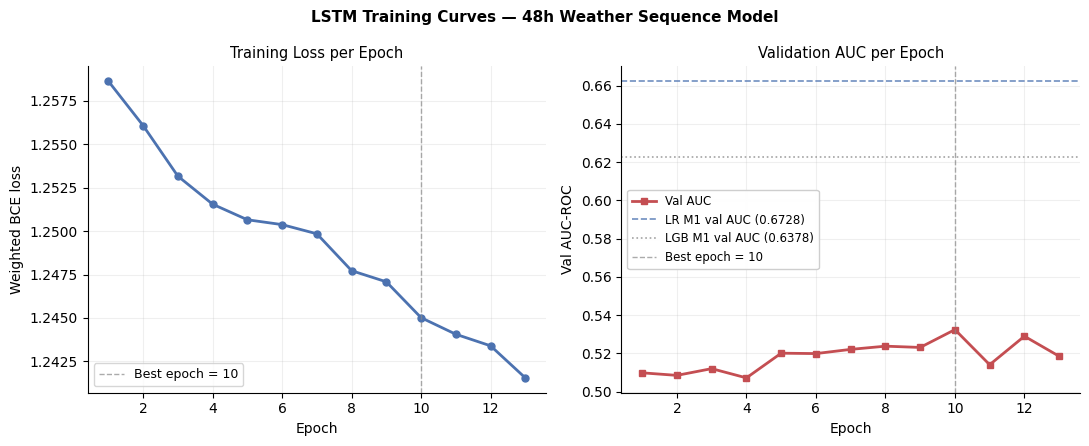

Saved: lstm_training_curves.png


In [7]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(ep_range, history['train_loss'], 'o-', color='#4C72B0', lw=2.0, ms=5)
ax1.axvline(best_epoch, color='#888888', ls='--', lw=1.0, alpha=0.7,
            label=f'Best epoch = {best_epoch}')
ax1.set_xlabel('Epoch', fontsize=10); ax1.set_ylabel('Weighted BCE loss', fontsize=10)
ax1.set_title('Training Loss per Epoch', fontsize=10.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(ep_range, history['val_auc'], 's-', color='#C44E52', lw=2.0, ms=5,
         label='Val AUC')
ax2.axhline(LR_AUC,  color='#4C72B0', ls='--', lw=1.2, alpha=0.8,
            label=f'LR M1 val AUC (0.6728)')
ax2.axhline(LGB_AUC, color='#8c8c8c', ls=':', lw=1.2, alpha=0.8,
            label=f'LGB M1 val AUC (0.6378)')
ax2.axvline(best_epoch, color='#888888', ls='--', lw=1.0, alpha=0.7,
            label=f'Best epoch = {best_epoch}')
ax2.set_xlabel('Epoch', fontsize=10); ax2.set_ylabel('Val AUC-ROC', fontsize=10)
ax2.set_title('Validation AUC per Epoch', fontsize=10.5)
ax2.legend(fontsize=8.5, framealpha=0.95); ax2.grid(alpha=0.2)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('LSTM Training Curves — 48h Weather Sequence Model',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lstm_training_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: lstm_training_curves.png')

## 8. Figure 2 — Temporal Saliency Analysis

Computing saliency on 1767 onset sequences ...


Saliency shape: (48, 5)
Peak sensitivity at t-5 hours before onset
Most important feature: shortwave_radiation


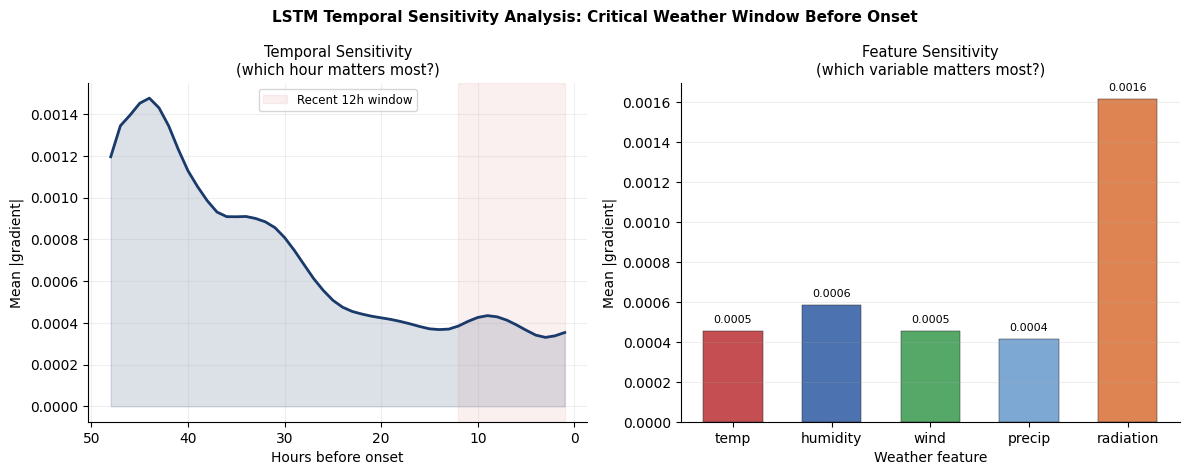

Saved: lstm_saliency.png

Key finding: Peak sensitivity at t-5 hours
Most important feature: shortwave_radiation


In [8]:
# Saliency: input gradients averaged over onset sequences (CPU for reliable autograd)
model_cpu = OutageLSTM().to('cpu')
model_cpu.load_state_dict({k: v.cpu() for k, v in best_state.items()})
model_cpu.eval()

onset_mask = y_te == 1
X_onset    = torch.from_numpy(X_te[onset_mask]).float()
print(f'Computing saliency on {onset_mask.sum()} onset sequences ...')

GRAD_BATCH = 128
all_grads  = []
for start in range(0, len(X_onset), GRAD_BATCH):
    xb  = X_onset[start : start + GRAD_BATCH].clone().requires_grad_(True)
    out = torch.sigmoid(model_cpu(xb))
    out.sum().backward()
    all_grads.append(xb.grad.abs().detach().numpy())

mean_grad       = np.concatenate(all_grads, axis=0).mean(axis=0)  # (48, 5)
grad_by_time    = mean_grad.mean(axis=1)
grad_by_feature = mean_grad.mean(axis=0)

print(f'Saliency shape: {mean_grad.shape}')
print(f'Peak sensitivity at t-{SEQ_LEN - int(np.argmax(grad_by_time))} hours before onset')
print(f'Most important feature: {SEQUENCE_FEATURES[np.argmax(grad_by_feature)]}')

fig, (axT, axF) = plt.subplots(1, 2, figsize=(12, 4.8))

hours_before = np.arange(SEQ_LEN, 0, -1)
axT.plot(hours_before, grad_by_time[::-1], color='#1a3a6b', lw=2.0)
axT.fill_between(hours_before, grad_by_time[::-1], alpha=0.15, color='#1a3a6b')
axT.axvspan(1, 12, alpha=0.08, color='#cc4444', label='Recent 12h window')
axT.set_xlabel('Hours before onset', fontsize=10)
axT.set_ylabel('Mean |gradient|', fontsize=10)
axT.set_title('Temporal Sensitivity\n(which hour matters most?)', fontsize=10.5)
axT.invert_xaxis()
axT.legend(fontsize=8.5)
axT.grid(alpha=0.2)
axT.spines[['top', 'right']].set_visible(False)

feat_labels = ['temp', 'humidity', 'wind', 'precip', 'radiation']
feat_colors = ['#C44E52', '#4C72B0', '#55A868', '#7ea8d4', '#DD8452']
bars = axF.bar(feat_labels, grad_by_feature, color=feat_colors,
               edgecolor='#2a2a2a', linewidth=0.35, width=0.6)
axF.set_xlabel('Weather feature', fontsize=10)
axF.set_ylabel('Mean |gradient|', fontsize=10)
axF.set_title('Feature Sensitivity\n(which variable matters most?)', fontsize=10.5)
axF.grid(axis='y', alpha=0.2)
axF.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, grad_by_feature):
    axF.text(bar.get_x() + bar.get_width()/2, bar.get_height() + grad_by_feature.max()*0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('LSTM Temporal Sensitivity Analysis: Critical Weather Window Before Onset',
             fontsize=11, fontweight='semibold')
plt.tight_layout()
fig.savefig(FIGURES_PATH + 'lstm_saliency.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: lstm_saliency.png')
print(f'\nKey finding: Peak sensitivity at t-{SEQ_LEN - int(np.argmax(grad_by_time))} hours')
print(f'Most important feature: {SEQUENCE_FEATURES[np.argmax(grad_by_feature)]}')

In [ ]:
# Save predictions for robustness_checks.ipynb
import numpy as np
PRED_DIR = '../data/predictions/'
import os; os.makedirs(PRED_DIR, exist_ok=True)

np.save(PRED_DIR + 'y_te.npy',           y_te)
np.save(PRED_DIR + 'cal_proba_lstm.npy', preds_te)

print('Saved to', PRED_DIR)
